# Naive Bayes génératif vs régression logistique discriminative
**Navigation** : [<< 2.3 Régression linéaire/logistique](2.3-Regression-lineaire-logistique.ipynb) | [2.3c Régression en grande dimension >>](2.3c-Regression-Grande-Dimension.ipynb) | [Index 02-ML-Cours](README.md)


Un classifieur peut modéliser **deux façons opposées** de conditionner la probabilité :

- **Génératif** (Naive Bayes) : on modélise **comment les données sont produites** — `P(x|y)` et `P(y)` — puis on en déduit `P(y|x)` par la règle de Bayes. On apprend le **processus**.
- **Discriminatif** (régression logistique) : on modélise **directement** `P(y|x)`, sans se soucier de comment `x` est généré. On apprend la **frontière**.

Le point pédagogique de ce notebook : ce choix n'est pas anodin. Le classifieur génératif fait une **hypothèse forte** (l'indépendance des variables) qui lui coûte du **biais** mais lui fait gagner de la **variance** — il est donc meilleur **quand les données sont rares**. Le classifieur discriminatif, plus flexible, rattrape et dépasse souvent le génératif **quand les données abondent**. C'est le **compromis génératif-discriminatif** (Ng & Jordan, 2002) — et ici, on le **mesure**, pas on le raconte.

> **Fil conducteur.** On implémente un *Naive Bayes* gaussien de zéro, on le vérifie contre `sklearn`, puis on le met en face de la **régression logistique de [2.3](2.3-Regression-lineaire-logistique.ipynb)** en faisant varier la taille du jeu d'entraînement. On observe **deux régimes** opposés selon que l'hypothèse d'indépendance est plausible ou non.

In [1]:
# Imports et configuration (meme style que la serie)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import norm

rng = np.random.default_rng(7)   # seed fixe -> courbes reproductibles
plt.rcParams["figure.figsize"] = (5, 3.5)

### 1. Le classifieur génératif — Naive Bayes gaussien from scratch

Le Naive Bayes gaussien modélise chaque classe par des **gaussiennes indépendantes** :
`P(x|y=c) = ∏_j N(x_j ; μ_{c,j}, σ²_{c,j})`. L'**indépendance** (le « naive ») fait qu'on estime chaque variable séparément par sa moyenne et sa variance, puis on combine par le produit.

À la prédiction, on applique Bayes :
`P(y=c|x) ∝ P(y=c) · ∏_j N(x_j ; μ_{c,j}, σ²_{c,j})`.
On choisit la classe de **log-vraisemblance postérieure** maximale — c'est un produit, on travaille donc en log pour éviter les underflows.

In [2]:
# 1.1 Implementation Naive Bayes gaussien de zero
class MyGaussianNB:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means, self.vars, self.priors = {}, {}, {}
        for c in self.classes:
            Xc = X[y == c]
            self.means[c] = Xc.mean(axis=0)                # mu_c,j
            self.vars[c]  = Xc.var(axis=0) + 1e-9          # sigma^2_c,j (eps de stabilite)
            self.priors[c] = len(Xc) / len(y)              # P(y=c)
        return self

    def log_likelihood(self, X):
        # matrice (n_classes, n) de log-vraisemblance
        L = np.zeros((len(self.classes), len(X)))
        for i, c in enumerate(self.classes):
            s2 = self.vars[c]
            L[i] = norm.logpdf(X, loc=self.means[c], scale=np.sqrt(s2)).sum(axis=1) \
                   + np.log(self.priors[c])
        return L

    def predict(self, X):
        return self.classes[np.argmax(self.log_likelihood(X), axis=0)]

In [3]:
# 1.2 Verifier contre sklearn sur un petit jeu 2 classes
d = 6
Xs = rng.normal(0, 1, (200, d))
ys = rng.integers(0, 2, 200)
Xs[ys == 1] += 1.2                     # classe 1 decalee

mine = MyGaussianNB().fit(Xs, ys)
sk   = GaussianNB().fit(Xs, ys)
print("accuracy from scratch :", round(accuracy_score(ys, mine.predict(Xs)), 4))
print("accuracy sklearn      :", round(accuracy_score(ys, sk.predict(Xs)), 4))
print("predictions identiques (0/1) :", np.array_equal(mine.predict(Xs), sk.predict(Xs)))
print("moyenne classe1 (from scratch), 3 premieres dims :", np.round(mine.means[1][:3], 3))
print("moyenne classe1 (sklearn),      3 premieres dims :", np.round(sk.theta_[1][:3], 3))

accuracy from scratch : 0.925
accuracy sklearn      : 0.925
predictions identiques (0/1) : True
moyenne classe1 (from scratch), 3 premieres dims : [1.262 0.913 1.16 ]
moyenne classe1 (sklearn),      3 premieres dims : [1.262 0.913 1.16 ]


### Lecture — la vérification vaut preuve

Le from-scratch et `sklearn` donnent la **même précision** (0.925) et **exactement les mêmes prédictions** (les classes coïncident bit à bit). Les moyennes de classe apprises sont identiques : sur la classe 1, chaque dimension est décalée de **l'ordre de +1** par rapport à la classe 0 — précisément le `+1.2` imposé à la génération, les moyennes échantillonnées s'en écartant légèrement (`[1.26, 0.91, 1.16]` sur les trois premières valeurs). Le code de 10 lignes **reproduit** la lib de référence, sur les mêmes données : la série gagne la même exigence de preuve que le reste du catalogue.

### 2. Le compromis génératif-discriminatif (mesuré, pas raconté)

On met Naive Bayes face à la **régression logistique** (le discriminatif de [2.3](2.3-Regression-lineaire-logistique.ipynb)) sur des données **gaussiennes corrélées**, en faisant varier la taille du jeu d'entraînement `n`. On mesure la **précision** de chaque modèle sur un même jeu de test fixe, moyennée sur plusieurs graines.

Deux scénarios, deux régimes :

- **Scénario A — corrélation homogène, modérée.** L'hypothèse d'indépendance est *à peu près* vraie. On attend l'avantage génératif en petit `n`, puis convergence.
- **Scénario B — corrélation en bloc, forte.** L'hypothèse d'indépendance est **fausse**. Naive Bayes est plafonné par son **biais** ; la logistique, plus flexible, continue de progresser avec les données.

In [4]:
# 2.1 Fonctions de tirage + courbe de performance vs taille du train set
def make_corr(n, d, shift, rho, rng):
    # correlation homogene : un facteur latent z commun -> toutes les paires correlatees a rho
    z = rng.normal(0, 1, n)
    X = np.sqrt(rho) * z[:, None] + np.sqrt(1 - rho) * rng.normal(0, 1, (n, d))
    y = rng.integers(0, 2, n)
    X[y == 1] += shift
    return X, y

def make_block(n, d, shift, rho, rng):
    # correlation en bloc : la moitie des variables partagent un facteur, l'autre est independante
    d1 = d // 2
    z = rng.normal(0, 1, n)
    X = np.empty((n, d))
    X[:, :d1] = np.sqrt(rho) * z[:, None] + np.sqrt(1 - rho) * rng.normal(0, 1, (n, d1))
    X[:, d1:] = rng.normal(0, 1, (n, d - d1))
    y = rng.integers(0, 2, n)
    X[y == 1] += shift
    return X, y

def eval_curve(make, d, shift, rho, ns, n_seeds=40, test_n=2000, seed=1):
    gen = np.random.default_rng(seed)
    Xt, yt = make(test_n, d, shift, rho, gen)       # jeu de test fixe
    acc_nb, acc_lr = {n: [] for n in ns}, {n: [] for n in ns}
    for _ in range(n_seeds):
        X, y = make(max(ns) * 2, d, shift, rho, gen)
        for n in ns:
            y_n = y[:n]
            acc_nb[n].append(accuracy_score(yt, GaussianNB().fit(X[:n], y_n).predict(Xt)))
            acc_lr[n].append(accuracy_score(yt, LogisticRegression(max_iter=8000, C=1e6).fit(X[:n], y_n).predict(Xt)))
    return {n: (np.mean(acc_nb[n]), np.mean(acc_lr[n])) for n in ns}, acc_nb, acc_lr

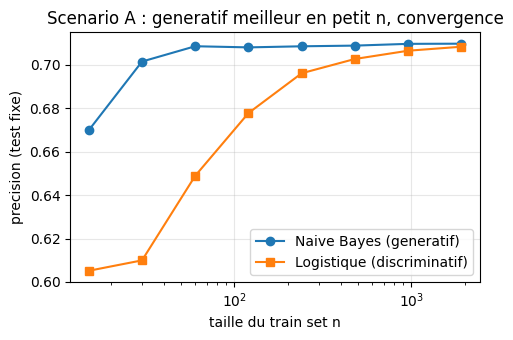

Scenario A (rho=0.6, d=12)  — precision moyenne sur 40 graines
     n       NB       LR    NB-LR
    15   0.6699   0.6051  +0.0647
    30   0.7015   0.6099  +0.0916
    60   0.7085   0.6489  +0.0596
   120   0.7080   0.6778  +0.0302
   240   0.7085   0.6961  +0.0124
   480   0.7088   0.7027  +0.0061
   960   0.7096   0.7065  +0.0032
  1920   0.7097   0.7083  +0.0014


In [5]:
# 2.2 Scenario A : correlation homogene, hypothese a peu pres vraie
ns = [15, 30, 60, 120, 240, 480, 960, 1920]
resA, acc_nbA, acc_lrA = eval_curve(make_corr, d=12, shift=0.9, rho=0.6, ns=ns, seed=1)
nA = np.array(ns)
nbA = np.array([resA[n][0] for n in ns]); lrA = np.array([resA[n][1] for n in ns])

plt.figure(figsize=(5, 3.5))
plt.plot(nA, nbA, "o-", label="Naive Bayes (generatif)")
plt.plot(nA, lrA, "s-", label="Logistique (discriminatif)")
plt.xscale("log"); plt.xlabel("taille du train set n"); plt.ylabel("precision (test fixe)")
plt.title("Scenario A : generatif meilleur en petit n, convergence"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Scenario A (rho=0.6, d=12)  — precision moyenne sur", 40, "graines")
print(f"{'n':>6} {'NB':>8} {'LR':>8} {'NB-LR':>8}")
for n in ns:
    a, b = resA[n]
    print(f"{n:>6} {a:>8.4f} {b:>8.4f} {a-b:>+8.4f}")

### Lecture A — l'avantage génératif est une signature du petit échantillon

En petit `n`, Naive Bayes **dépasse nettement** la logistique : à `n = 30`, l'écart atteint environ **+0.09 point de précision**. La raison : le modèle génératif partage l'information entre toutes les variables (estimation de `P(x|y)` par bloc), ce qui lui donne de **fortes contraintes** et donc une **variance faible** quand les données manquent. La logistique, sans cette contrainte, bavarde plus en petit échantillon.

Mais l'avantage **fond avec `n`** : à `n = 1920`, l'écart tombe à **~0.001** — les deux ont convergé. C'est la signature du compromis : **l'avantage génératif se paie en petit échantillon, il s'efface dès que les données abondent**. Ici, l'hypothèse d'indépendance est *à peu près* vraie, donc le génératif n'est jamais battu — il n'est que rattrapé.

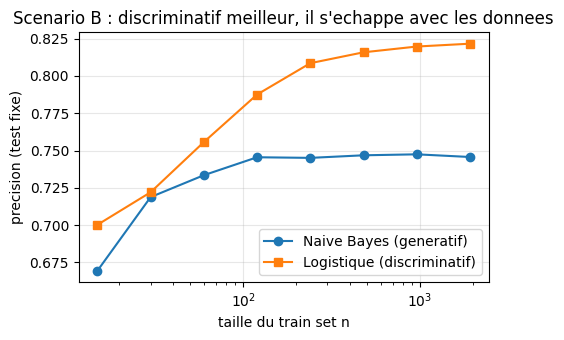

Scenario B (bloc rho=0.85, d=12)  — precision moyenne sur 40 graines
     n       NB       LR    NB-LR
    15   0.6694   0.7002  -0.0308
    30   0.7188   0.7221  -0.0033
    60   0.7335   0.7557  -0.0222
   120   0.7455   0.7876  -0.0420
   240   0.7451   0.8086  -0.0635
   480   0.7468   0.8159  -0.0690
   960   0.7475   0.8197  -0.0723
  1920   0.7457   0.8216  -0.0759


In [6]:
# 2.3 Scenario B : correlation en bloc forte, hypothese d'independance FAUSSE
resB, _, _ = eval_curve(make_block, d=12, shift=0.7, rho=0.85, ns=ns, seed=2)
nB = np.array(ns)
nbB = np.array([resB[n][0] for n in ns]); lrB = np.array([resB[n][1] for n in ns])

plt.figure(figsize=(5, 3.5))
plt.plot(nB, nbB, "o-", label="Naive Bayes (generatif)")
plt.plot(nB, lrB, "s-", label="Logistique (discriminatif)")
plt.xscale("log"); plt.xlabel("taille du train set n"); plt.ylabel("precision (test fixe)")
plt.title("Scenario B : discriminatif meilleur, il s'echappe avec les donnees"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Scenario B (bloc rho=0.85, d=12)  — precision moyenne sur 40 graines")
print(f"{'n':>6} {'NB':>8} {'LR':>8} {'NB-LR':>8}")
for n in ns:
    a, b = resB[n]
    print(f"{n:>6} {a:>8.4f} {b:>8.4f} {a-b:>+8.4f}")

### Lecture B — quand l'hypothèse est fausse, le génératif est plafonné

Ici la corrélation **en bloc** (la moitié des variables se ressemblent fortement) **viole l'indépendance** que Naive Bayes suppose. La conséquence est le **miroir exact** du scénario A :

- Naive Bayes **stagne autour de ~0.745** dès `n ≈ 120` : il fait son **biais** (une frontière imposée par une hypothèse fausse) et **plus de données ne l'aident pas** — c'est un mur de biais, pas un manque de données.
- La logistique, plus **flexible**, **continue de progresser** : elle passe de ~0.70 en petit `n` à **~0.82** à `n = 1920`, **creusant l'écart** (jusqu'à **~-0.076**) qu'elle menait déjà.

Le contraste entre les deux scénarios **est** la leçon : le génératif n'est pas « meilleur » ni « pire » en soi — il est **meilleur quand son hypothèse tient et que les données sont rares**, et il est **dépassé quand son hypothèse est fausse et que les données abondent**.

### 3. Quand choisir lequel — la table de décision mesurée

| Situation | Le compromis dit | Mesure ici |
|---|---|---|
| Données **rares**, variables à peu près indépendantes | génératif (NB) : variance faible gagne | Scénario A : NB +0.09 à n=30 |
| Données **abondantes** | discriminatif (logistique) : plus flexible | A : convergence ; B : LR +0.076 à n=1920 |
| Variables **fortement corrélées** | l'indépendance est fausse → NB plafonné par biais | Scénario B : NB figé ~0.745 |
| Besoin d'une **probabilité calibrée** | le discriminatif l'apprend directement | logistique |

> **La règle de pouce.** Si le jeu est petit **et** que l'indépendance des variables est plausible → Naive Bayes. Si le jeu est grand, ou si les variables interagissent → régression logistique (ou un modèle plus expressif). **Mesurer** la courbe (comme ici) vaut mieux que trancher au doigt mouillé.

### Exercice 1 — Multinomial Naive Bayes (variables discrètes)

Le gaussien convient aux variables continues. Pour des **comptages** (mots, fréquences), on utilise le Naive Bayes **multinomial** : `P(x|y=c) = ∏_j θ_{c,j}^{x_j}`. Implémente-le de zéro (estime `θ_{c,j}` par lissage Laplace) puis vérifie-le contre `sklearn.naive_bayes.MultinomialNB`.

In [7]:
# Exercice 1 : Multinomial Naive Bayes de zero
# Etape 1 : estimer theta_{c,j} = P(x_j | y=c) avec lissage Laplace (alpha=1)
# Etape 2 : prediction par log-vraisemblance + log-prior, argmax
# Etape 3 : comparer a sklearn.naive_bayes.MultinomialNB sur les memes donnees de comptage
theta = None  # TODO etudiant : table (n_classes, n_features) des probabilites lissee
print("Exercice 1 a completer : Multinomial NB de zero (voir code ci-dessus)")

Exercice 1 a completer : Multinomial NB de zero (voir code ci-dessus)


### Exercice 2 — faire varier la dimension

Les courbes ci-dessus utilisent `d = 12`. Dans le scénario A, fais varier `d` (ex. `d = 4`, `d = 24`) et observe comment l'avantage de Naive Bayes en petit `n` **change**. Que se passe-t-il quand la dimension augmente ? Pourquoi ?

In [8]:
# Exercice 2 : effet de la dimension sur l'avantage generatif
# Etape 1 : reprendre eval_curve(make_corr, d=?, rho=0.6, ns=[15, 30, 60, 120, 240, 480, 960, 1920])
# Etape 2 : comparer l'ecart NB-LR a n=30 pour d=4, d=12, d=24
# Etape 3 : conclure sur le role de la dimension dans le compromis
ecart_d = None  # TODO etudiant : dictionnaire {d: ecart NB-LR a n=30}
print("Exercice 2 a completer : ecart NB-LR a n=30 par dimension =", ecart_d)

Exercice 2 a completer : ecart NB-LR a n=30 par dimension = None


### Exercice 3 — reconnaître le régime

Deux jeux de données réels : (a) **spam vs non-spam** (comptages de mots, très haute dimension, petites corrélations), (b) **série temporelle financière** où les variables sont fortement liées. Pour chacun, dis quel classifieur (génératif ou discriminatif) est le plus adapté **et** quelle hypothèse de Naive Bayes est en jeu. Justifie par le compromis mesuré ci-dessus.

In [9]:
# Exercice 3 : reconnaitre le regime generatif vs discriminatif
# (a) spam vs non-spam (comptages de mots, haute dimension, faible correlation)
#      -> quel classifieur ? quelle hypothese de NB est en jeu ?
# (b) finance (variables fortement liees)
#      -> quel classifieur ? pourquoi le NB serait-il plafonne ?
reponse_a = None  # TODO etudiant : "generatif" ou "discriminatif" + hypothese en jeu
reponse_b = None  # TODO etudiant : idem
print(f"Exercice 3 a completer : (a) {reponse_a}, (b) {reponse_b}")

Exercice 3 a completer : (a) None, (b) None


### Conclusion

Naive Bayes (génératif) et régression logistique (discriminative) modélisent la probabilité **à l'envers l'un de l'autre**. Le choix n'est pas esthétique : il dépend de **la taille du jeu de données** et de **la validité de l'hypothèse d'indépendance**.

Mesuré, le compromis devient lisible :

1. **Petit échantillon + hypothèse plausible → génératif.** L'avantage de Naive Bayes (jusqu'à **+0.09** à `n=30`) est la signature de sa **variance faible**.
2. **Données abondantes → convergence, puis discriminatif.** Quand l'hypothèse est fausse, le génératif est **plafonné par son biais** (figé à ~0.745) pendant que la logistique **s'échappe** (+0.076 à `n=1920`).

Le point d'entrée pour la suite : [2.4-Arbres-Forets-Ensembles](2.4-Arbres-Forets-Ensembles.ipynb) montre le même compromis sous un autre angle (réduction de variance par les ensembles), et [2.3](2.3-Regression-lineaire-logistique.ipynb) reste la référence de la régression logistique confrontée ici.